04 — Tree models

Three flavours of tree on the same features and the same split:
a single decision tree (interpretable baseline), Random Forest (bagging),
and LightGBM (boosting). LightGBM was the dominant method in the original
ASHRAE GEPIII competition (Miller et al. 2022a), so it is the standard the
rest of the project measures itself against.

In [1]:
from __future__ import annotations

import warnings
warnings.filterwarnings("ignore")

import os
os.environ.setdefault("OMP_NUM_THREADS", "1")
os.environ.setdefault("MKL_NUM_THREADS", "1")
os.environ.setdefault("MPLCONFIGDIR", str(__import__("pathlib").Path.cwd() / ".mplcache"))
os.makedirs(os.environ["MPLCONFIGDIR"], exist_ok=True)

from pathlib import Path
import json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from src.config import load_config
from src.pipeline import prepare_data
from src.models import DecisionTreeModel, RandomForestModel, LightGBMModel
from src.viz.style import set_style, save_figure, PRIMARY, ACCENT, SUPPORT

set_style()
PLOT_DIR = Path("../results/plots/trees")
PLOT_DIR.mkdir(parents=True, exist_ok=True)

cfg = load_config("../configs/default.yaml")
prep = prepare_data(cfg, feature_set="engineered")
X_train, y_train = prep.train_full[prep.feature_cols], prep.target_log_train
X_val, y_val = prep.val_full[prep.feature_cols], prep.target_log_val


Single decision tree — varying max_depth

Sweeping `max_depth` shows the bias-variance trade-off cleanly: shallow trees
under-fit, very deep trees over-fit, and the elbow tells us where to set the
default before bagging or boosting kicks in.

depth 4: RMSE 5732.9  (20.2s)


depth 8: RMSE 4625.2  (38.8s)


depth 12: RMSE 4687.4  (56.1s)


depth 16: RMSE 4987.2  (71.4s)


depth 20: RMSE 4990.2  (83.0s)


depth 24: RMSE 4990.5  (90.2s)


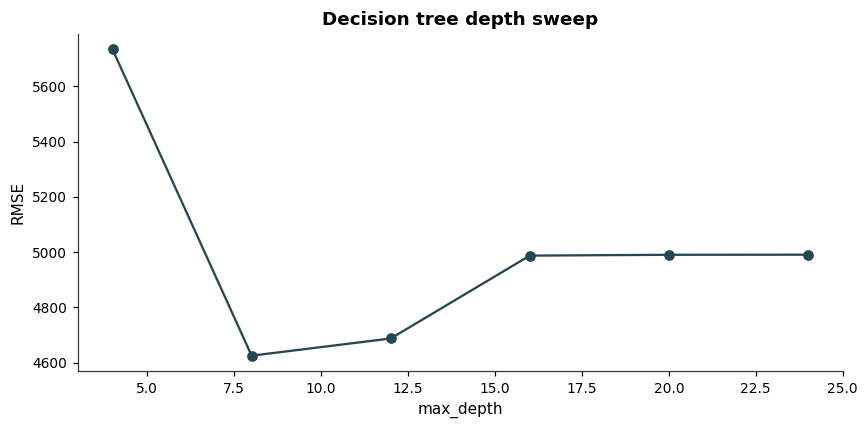

,max_depth,rmse,train_seconds
0,4,5732.915008,20.228081
1,8,4625.232782,38.825198
2,12,4687.433444,56.081477
3,16,4987.203609,71.362652
4,20,4990.190628,83.015023
5,24,4990.544810,90.188601


In [2]:
depths = [4, 8, 12, 16, 20, 24]
dt_rows = []
for d in depths:
    m = DecisionTreeModel(max_depth=d)
    preds, secs = m.fit_predict(X_train, y_train, X_val)
    pred_real = np.expm1(np.clip(preds, 0.0, 14.0))
    actual_real = np.expm1(np.clip(y_val, 0.0, 14.0))
    rmse = float(np.sqrt(np.mean((pred_real - actual_real) ** 2)))
    dt_rows.append({"max_depth": d, "rmse": rmse, "train_seconds": secs})
    print(f"depth {d}: RMSE {rmse:.1f}  ({secs:.1f}s)")
dt_curve = pd.DataFrame(dt_rows)

fig, ax = plt.subplots(figsize=(8, 4))
ax.plot(dt_curve["max_depth"], dt_curve["rmse"], marker="o", color=PRIMARY)
ax.set_xlabel("max_depth")
ax.set_ylabel("RMSE")
ax.set_title("Decision tree depth sweep")
plt.tight_layout()
save_figure(fig, PLOT_DIR / "dt_depth_sweep")
plt.show()
dt_curve


Random Forest

In [3]:
rf_params = cfg.models.get("random_forest", {})
rf = RandomForestModel(**rf_params)
rf_preds, rf_secs = rf.fit_predict(X_train, y_train, X_val)
rf_real = np.expm1(np.clip(rf_preds, 0.0, 14.0))
y_val_real = np.expm1(np.clip(y_val, 0.0, 14.0))
rf_rmse = float(np.sqrt(np.mean((rf_real - y_val_real) ** 2)))
print(f"RF RMSE: {rf_rmse:.1f}  ({rf_secs:.1f}s)")


RF RMSE: 4314.1  (885.4s)


LightGBM

In [4]:
lgb_params = cfg.models.get("lightgbm", {})
lgb = LightGBMModel(**lgb_params)
lgb.fit(X_train, y_train, eval_set=(X_val, y_val))
lgb_preds = lgb.predict(X_val)
lgb_real = np.expm1(np.clip(lgb_preds, 0.0, 14.0))
lgb_rmse = float(np.sqrt(np.mean((lgb_real - y_val_real) ** 2)))
print(f"LightGBM RMSE: {lgb_rmse:.1f}")


LightGBM RMSE: 5730.6


Feature importance — both models

LightGBM importance is `gain` (total gain from splits using a feature). Random
Forest is `mean decrease in impurity`. They tend to agree on the top features but
disagree on the long tail.

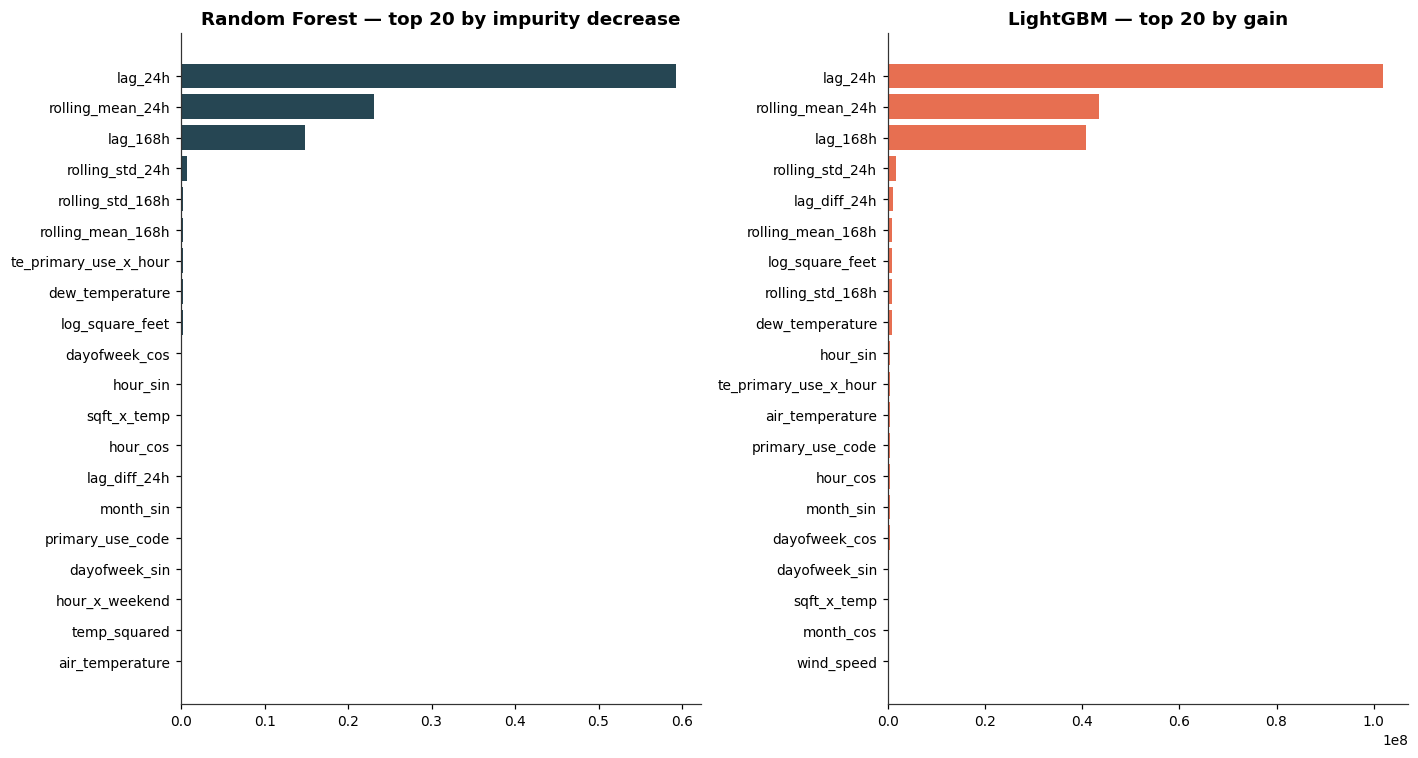

In [5]:
def to_series(d: dict) -> pd.Series:
    return pd.Series(d).sort_values(ascending=False)

rf_imp = to_series(rf.feature_importance() or {})
lgb_imp = to_series(lgb.feature_importance() or {})

fig, axes = plt.subplots(1, 2, figsize=(13, 7))
top_rf = rf_imp.head(20)[::-1]
axes[0].barh(top_rf.index, top_rf.values, color=PRIMARY)
axes[0].set_title("Random Forest — top 20 by impurity decrease")
top_lgb = lgb_imp.head(20)[::-1]
axes[1].barh(top_lgb.index, top_lgb.values, color=ACCENT)
axes[1].set_title("LightGBM — top 20 by gain")
plt.tight_layout()
save_figure(fig, PLOT_DIR / "feature_importance")
plt.show()


Predicted vs. actual

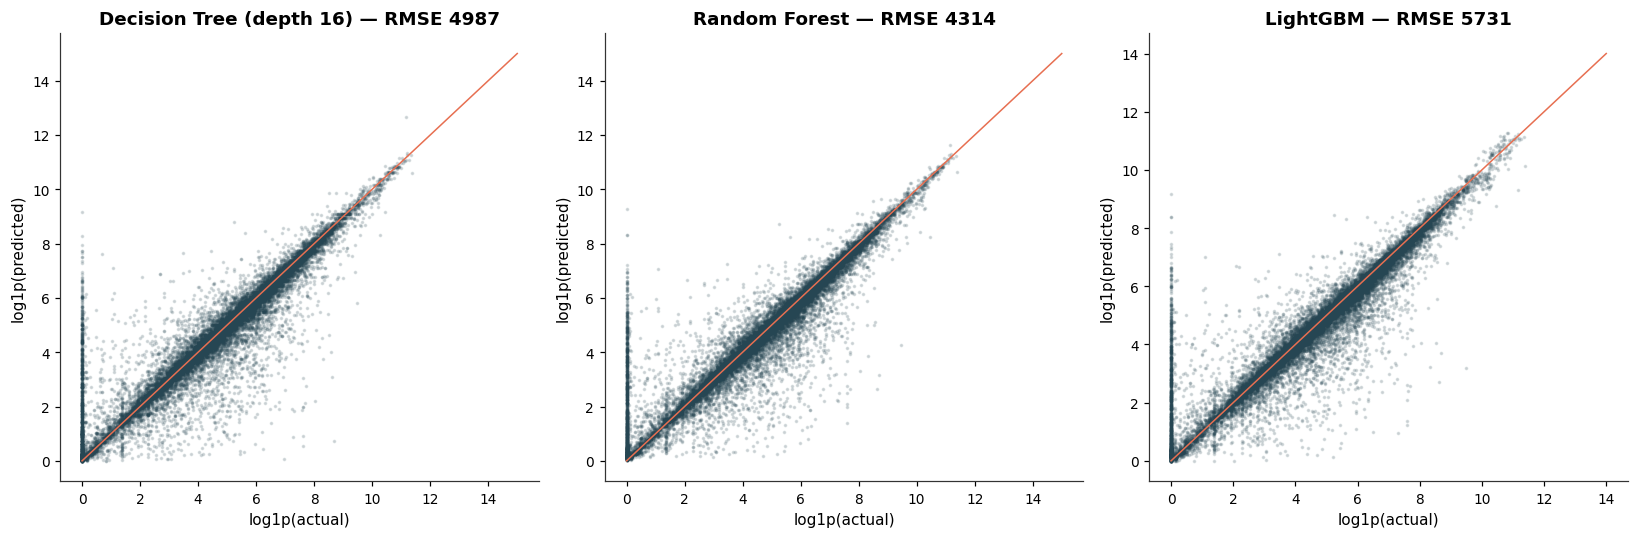

In [6]:
fig, axes = plt.subplots(1, 3, figsize=(15, 5))
for ax, name, preds in [
    (axes[0], "Decision Tree (depth 16)", DecisionTreeModel(max_depth=16).fit_predict(X_train, y_train, X_val)[0]),
    (axes[1], "Random Forest", rf_preds),
    (axes[2], "LightGBM", lgb_preds),
]:
    pr = np.expm1(np.clip(preds, 0.0, 14.0))
    sample = np.random.default_rng(0).choice(len(pr), size=min(30_000, len(pr)), replace=False)
    ax.scatter(np.log1p(y_val_real[sample]), np.log1p(pr[sample]),
               s=2, alpha=0.15, color=PRIMARY)
    lo = 0; hi = max(np.log1p(y_val_real.max()), np.log1p(pr.max()) + 1)
    ax.plot([lo, hi], [lo, hi], color=ACCENT, linewidth=1)
    rm = float(np.sqrt(np.mean((pr - y_val_real) ** 2)))
    ax.set_title(f"{name} — RMSE {rm:.0f}")
    ax.set_xlabel("log1p(actual)")
    ax.set_ylabel("log1p(predicted)")
plt.tight_layout()
save_figure(fig, PLOT_DIR / "tree_pred_vs_actual")
plt.show()


Per-primary-use breakdown for LightGBM

In [7]:
val = prep.val_full.copy()
val["y_true"] = y_val_real
val["y_pred"] = lgb_real
by_use = (
    val.groupby("primary_use", observed=True)
       .apply(lambda d: pd.Series({
           "n": len(d),
           "rmse": float(np.sqrt(np.mean((d["y_pred"] - d["y_true"]) ** 2))),
           "cv_rmse": float(np.sqrt(np.mean((d["y_pred"] - d["y_true"]) ** 2)) /
                            max(d["y_true"].mean(), 1e-6)),
       }))
       .sort_values("cv_rmse", ascending=False)
)
by_use


,n,rmse,cv_rmse
primary_use,,,
Education,694452.0,9540.304995,11.994162
Office,616371.0,1069.853124,1.348140
Lodging/residential,171347.0,710.120330,1.310348
Services,13242.0,7683.410589,0.996176
Food sales and service,27125.0,340.474331,0.891342
Entertainment/public assembly,173208.0,293.034302,0.874734
Parking,35295.0,245.694072,0.791339
Public services,107052.0,619.025523,0.766002
Religious worship,2207.0,0.715265,0.592297


In [8]:
out_dir = Path("../results/tables")
out_dir.mkdir(parents=True, exist_ok=True)
dt_curve.to_csv(out_dir / "trees_dt_depth_sweep.csv", index=False)
pd.DataFrame({
    "model": ["random_forest", "lightgbm"],
    "rmse": [rf_rmse, lgb_rmse],
}).to_csv(out_dir / "trees_summary.csv", index=False)
by_use.to_csv(out_dir / "lightgbm_per_primary_use.csv")
print(f"wrote tables to {out_dir}")


wrote tables to ../results/tables
